In [31]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [46]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [3]:
# loading data
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*.h5td"): 

    tdatas[file_path.stem] = td.read_h5td(file_path)

In [4]:
merged_tdata = td.concat(tdatas, merge ='unique')

In [5]:
del tdatas

In [16]:
merged_tdata.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree
E8.5-R1-T2-AGCCTGACATAAGCTA-1,Midbrain,E8.5-R1-T2,E8.5-R1,E8.5,donor,38226.0,48.0,0.939394,0.424242,E8.5-R1-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-GCAGCCATCTGTAAGT-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,21301.0,6.0,0.878788,0.397849,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-TGATCCCCATGGTTAA-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,23958.0,8.0,0.969697,0.421569,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T1-CGTACAGCAACGTGCA-1,Telencephalon (dorsal),E8.5-R1-T1,E8.5-R1,E8.5,donor,48821.0,14.0,0.969697,0.431373,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-ACGCGGTCAACCAACG-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,31433.0,17.0,0.939394,0.444444,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E9.5-R3-T16-TGTCTCACAATCCGTC-1,Sclerotome,E9.5-R3-T16,E9.5-R3,E9.5,donor,5098.0,2.0,0.727273,NaN,NaN,G2/M,Sclerotome,Mesoderm,Paraxial mesoderm,NaN
E9.5-R3-T16-TGTCTCACATGCAGAT-1,Telencephalon (ventral),E9.5-R3-T16,E9.5-R3,E9.5,donor,9886.0,8.0,0.727273,NaN,NaN,S,Telencephalon,Ectoderm,Neural ectoderm,NaN
E9.5-R3-T16-TGTCTGTTCACACAGC-1,Primitive erythrocyte,E9.5-R3-T16,E9.5-R3,E9.5,NaN,11618.0,7.0,NaN,NaN,NaN,G2/M,Primitive erythrocyte,Mesoderm,Blood,NaN
E9.5-R3-T16-TGTCTTGCAGCAGGTC-1,Telencephalon (dorsal),E9.5-R3-T16,E9.5-R3,E9.5,host,14909.0,13.0,NaN,NaN,NaN,S,Telencephalon,Ectoderm,Neural ectoderm,NaN


### Checking Dropout Count

In [6]:
# Converting non integer values into integers
chars = merged_tdata.obsm['characters']

# Cleaning up the character matrix so it contains only string
chars = np.where(chars == '*', 0, chars) # no edit
chars = np.where(chars == '-', -1, chars) # not detected
chars = np.where(chars == "!", 999, chars) # Not editable, but is detected

# Note, those classifications were given by claude. Need to confirm with the author whether those are actually the correct labeling
chars = chars.astype(int)

In [7]:
merged_tdata.obsm['X_characters'] = chars

Total cells: 1792634
Total cell per time point: stage
E7.5        4648
E8.0       21942
E8.5       88508
E9.0      249042
E9.5     1044095
E10.0     328848
Name: type, dtype: int64
Total cell per time replicate embryo
E7.5-R1       1342
E7.5-R2       1838
E7.5-R3       1468
E8.0-R1       4498
E8.0-R2      10681
E8.0-R3       6763
E8.5-R1      23315
E8.5-R2      38013
E8.5-R3      27180
E9.0-R1      89291
E9.0-R2      97771
E9.0-R3      61980
E9.5-R1     370973
E9.5-R2     340473
E9.5-R3     332649
E10.0-R1    328848
Name: type, dtype: int64


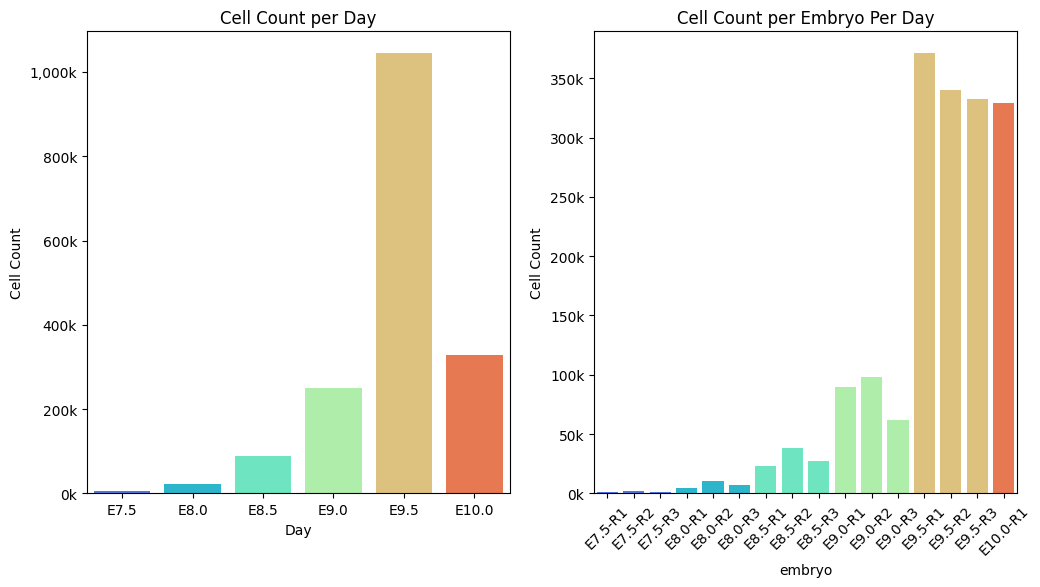

In [48]:
total_cells = len(chars)
print("Total cells:", total_cells)

# Init plot
rainbow_6 = sns.color_palette("rainbow", 6)
fig_1, axes_1= plt.subplots(figsize=(12,6 ), dpi=100, ncols = 2)

# Per Day Cell Count
total_cell_per_time_point = merged_tdata.obs.groupby('stage')['type'].count()
print("Total cell per time point:",total_cell_per_time_point)

sns.barplot(total_cell_per_time_point, ax=axes_1[0], palette = rainbow_6)
axes_1[0].set_title("Cell Count per Day")
axes_1[0].set_xlabel("Day")
axes_1[0].set_ylabel("Cell Count")
axes_1[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x*1e-3:,.0f}k"))

# Per Embryo Cell Count
total_cell_per_time_replicate = merged_tdata.obs.groupby('embryo')['type'].count()
print("Total cell per time replicate", total_cell_per_time_replicate)

sns.barplot(total_cell_per_time_replicate, ax=axes_1[1], palette = [color for color in rainbow_6 for _ in range(3)])
axes_1[1].set_title("Cell Count per Embryo Per Day")
axes_1[1].set_ylabel("Embryo")
axes_1[1].set_ylabel("Cell Count")
axes_1[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x*1e-3:,.0f}k"))

plt.xticks(rotation=45)
fig_1.savefig(output_plot+"cell_count.png")


stage
E7.5     0.778897
E8.0     0.766119
E8.5     0.698221
E9.0     0.893342
E9.5     0.723458
E10.0    0.778189
Name: barcode_coverage, dtype: float64
cell_type
Allantoic endothelial progenitor    0.762209
Allantois                           0.780540
Amniotic ectoderm                   0.615582
Anterior mesoderm                   0.835474
Arterial endothelial cell           0.720267
                                      ...   
Trigeminal placode                  0.859885
Trigeminal sensory neuron           0.748756
Trunk neural crest                  0.869894
Vagal neural crest                  0.864718
Visceral endoderm                   0.009499
Name: barcode_coverage, Length: 97, dtype: float64


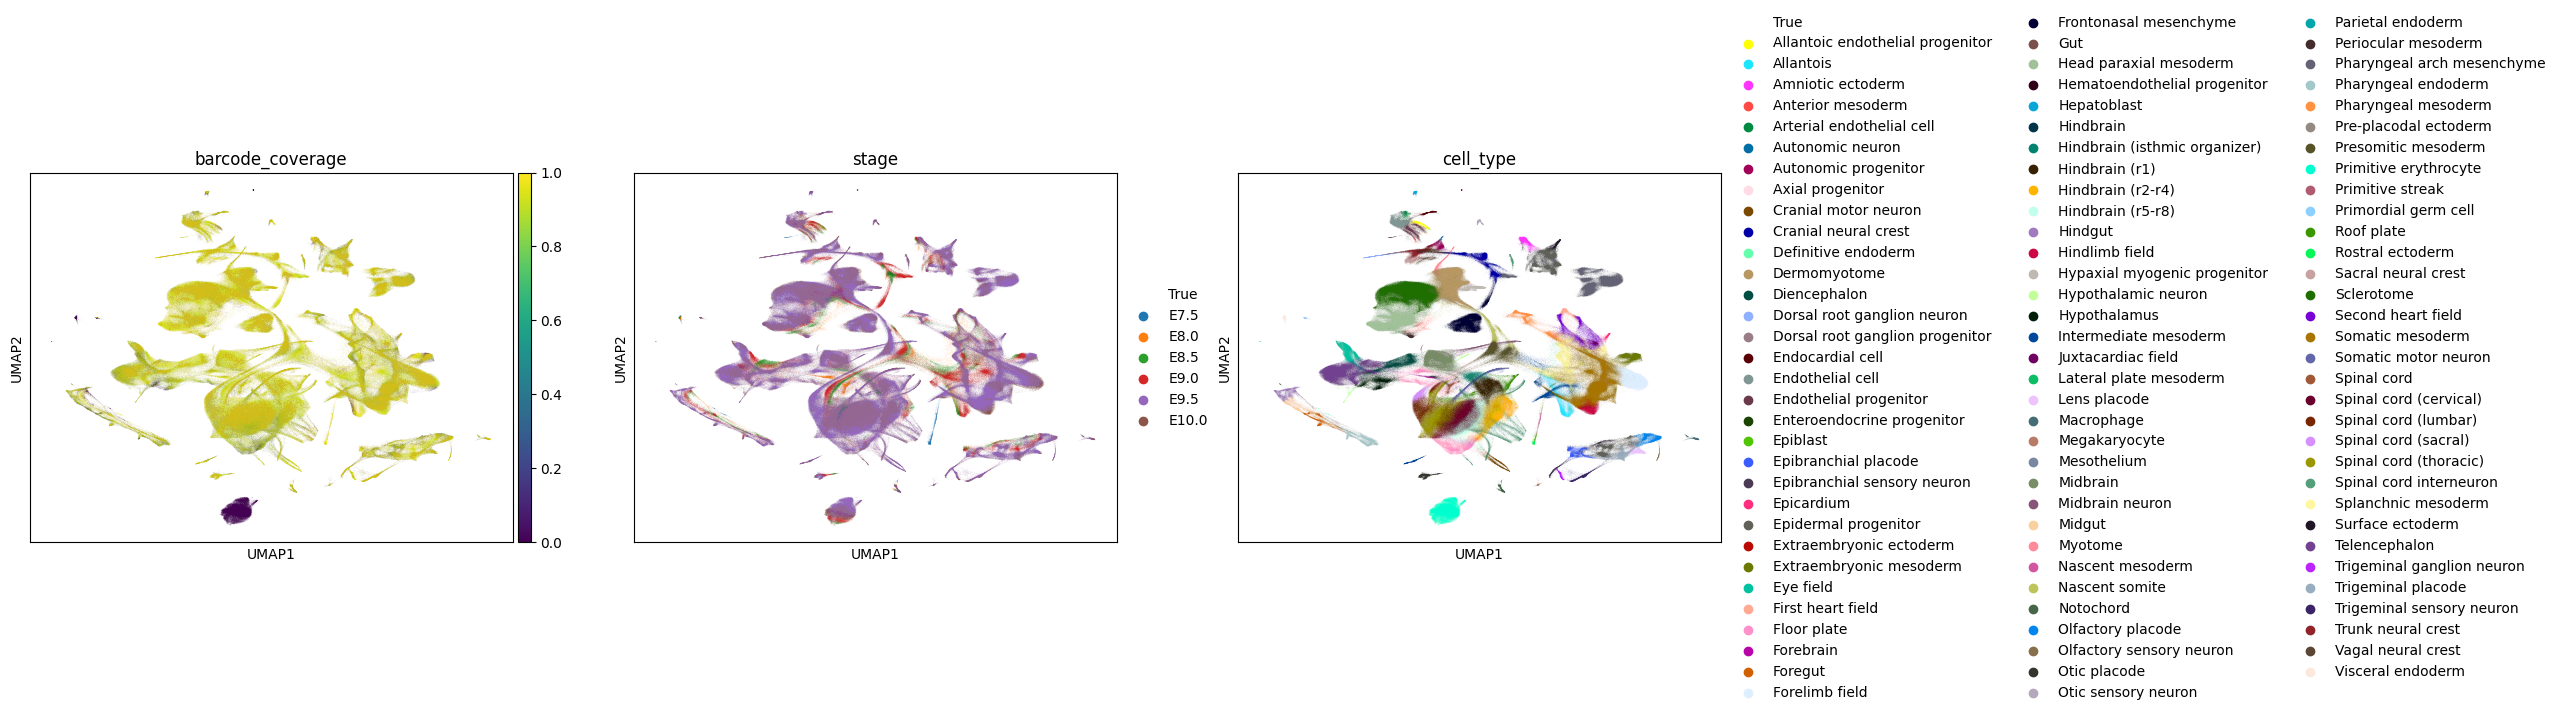

In [66]:
frac_observed = (merged_tdata.obsm["X_characters"] >= 0).mean(axis=1)
merged_tdata.obs["barcode_coverage"] = frac_observed

# Is dropout biased by time point?
print(merged_tdata.obs.groupby("stage")["barcode_coverage"].mean())

# Is dropout biased by cell type?
print(merged_tdata.obs.groupby("cell_type")["barcode_coverage"].mean().tail(5))

# Visualize on UMAP
sc.pl.umap(merged_tdata, color=["barcode_coverage", 'stage', 'cell_type'], label=True, show = False)
plt.savefig(output_plot+"Umap_Barcode_coverage.png", dpi = 300, bbox_inches = 'tight')

Text(0, 0.5, 'Percentage of cells')

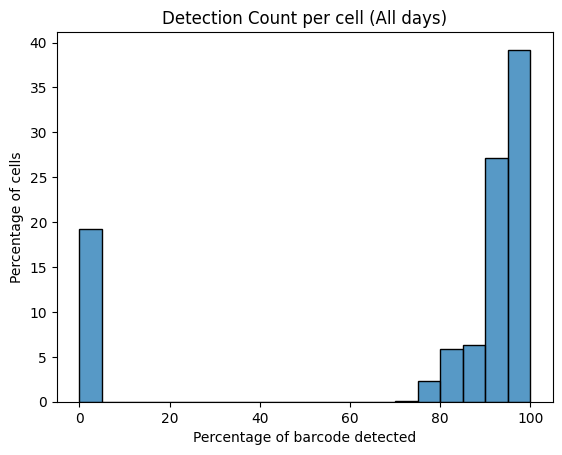

In [65]:
detection_count = (chars != -1).sum(axis=1) / len(chars[0]) *100
sns.histplot(detection_count, stat='percent', bins = 20)
plt.title("Detection Count per cell (All days)")
plt.xlabel("Percentage of barcode detected")
plt.ylabel("Percentage of cells")

In [70]:
# Same graph as above, but combined into one figure with one subplot per stage

detection_df = pd.DataFrame({
    "detection_pct": detection_count,
    "stage": merged_tdata.obs["stage"].astype(str).values,
})

stage_order = sorted(
    detection_df["stage"].unique(),
    key=lambda x: float(x.split("-")[0][1:]) if isinstance(x, str) and x.startswith("E") else x,
)

palette = rainbow_6[: len(stage_order)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=100, sharex=True, sharey=True)
axes = axes.ravel()

for i, stage in enumerate(stage_order):
    stage_df = detection_df[detection_df["stage"] == stage]
    sns.histplot(
        stage_df["detection_pct"],
        stat="percent",
        bins=20,
        color=palette[i],
        ax=axes[i],
        edgecolor="black",
        alpha=0.7,
    )
    axes[i].set_title(stage)
    axes[i].set_xlim(0, 100)
    if i % 3 == 0:
        axes[i].set_ylabel("Percentage of cells")
    if i >= 3:
        axes[i].set_xlabel("Percentage of barcode detected")

for j in range(len(stage_order), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Detection Count per cell by stage", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(output_plot + "detection_count_by_stage_subplot.png", dpi=300, bbox_inches='tight')
plt.close(fig)